# The Solow Growth Model and its Convergence Prediction
Replication: A Contribution to the Empirics of Economic Growth by Mankiw, Romer, and Weil (1992)

- Is the Solow model of economic growth consistent with the cross-country data?
- What is the augmented Solow model? Is it consistent with the data?
- What are the implications of the Solow model for convergence in standards of living across countries?
- Do poor countries tend to grow faster than rich countries?

**REQUIRED BACKGROUND:** To follow the main ideas of this computational notebook, a [basic understanding of the Solow model](https://wke.lt/w/s/NOD3t3) is needed.

**NOTE**: Stata code to replicate the main tables and figures is [available in this Github gist](https://gist.github.com/cmg777/a1181c89de80e5eb5e8c8be2383342d1)

In [1]:
# @title Watch the video
install.packages('IRdisplay')
library(IRdisplay)
# URL of the YouTube video
video_url <- "https://www.youtube.com/embed/md0cjl51JTk"

# HTML code to embed the video
embed_code <- sprintf('<iframe width="560" height="315" src="%s" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>', video_url)

# Display the embedded video
display_html(embed_code)


The downloaded binary packages are in
	/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T//Rtmp9Bmdr6/downloaded_packages


## Introduction

Solow (1956) proposed to study economic growth based on

  - A standard neoclassical production function with decreasing marginal returns to capital.
  - Exogenous rates of saving and population growth

Because saving and population growth rates vary across countries, different countries reach different steady states (long-run equilibria).

Testable predictions:

  - The higher the rate of saving, the richer the country.
  - The higher the rate of population growth, the poorer the country.

Motivation for including human capital accumulation:

  - The impact of higher savings (or lower population growth) is greater when human capital is taken into account. (Intuition: For a given (initially constant) $h$, $\uparrow s \Rightarrow  \uparrow y \Rightarrow \uparrow h \Rightarrow  \uparrow y$  )
  - Human capital may be correlated with savings and population growth rates. Thus, if it is omitted, the estimated coefficients are (upwardly) biased.

How to measure human capital accumulation?

  - Percentage of the working-age population tha is in secondary school.
  - Ignores investment in health, among other things


The Solow model and its convergence prediction:

  - In the data, countries do NOT convergence to the same per-capita income.
  - But recall that the Solow model predicts conditional convergence (multiple steady states), not unconditional convergence (single steady state)
      - Conditional convergence: countries converge to their own steady states, which are determined by saving, population growth, and education


## R Libraries and dataset

In [2]:
# Install necessary packages if they are not already installed
if (!requireNamespace("tibble", quietly = TRUE)) install.packages("tibble")
if (!requireNamespace("stargazer", quietly = TRUE)) install.packages("stargazer")
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2")
if (!requireNamespace("dplyr", quietly = TRUE)) install.packages("dplyr")
if (!requireNamespace("car", quietly = TRUE)) install.packages("car")
if (!requireNamespace("haven", quietly = TRUE)) install.packages("haven")

# Load libraries
library(tibble)     # nice dataframes
library(stargazer)  # regression tables
library(ggplot2)    # nice graphs
library(dplyr)      # data manipulation
library(car)        # test linear hypotheses
library(haven)      # reading stata data

# Set options
options(warn = -1)
options(scipen = 10000)
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 150)  # Adjust the width and height as needed



The downloaded binary packages are in
	/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T//Rtmp9Bmdr6/downloaded_packages


also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘Rcpp’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’





The downloaded binary packages are in
	/var/folders/tq/t98kb27n6djgrh085g476yhc0000gn/T//Rtmp9Bmdr6/downloaded_packages



Please cite as: 




 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.



...

The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:dplyr’:

    recode




In [3]:
mrw_data <- read_dta("https://github.com/quarcs-lab/data-quarcs/raw/master/mrw1992/mrw2.dta")

In [4]:
str(mrw_data)
summary(mrw_data)

tibble [121 × 12] (S3: tbl_df/tbl/data.frame)
 $ number   : num [1:121] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "format.stata")= chr "%8.0g"
 $ country  : chr [1:121] "Algeria" "Angola" "Benin" "Botswana" ...
  ..- attr(*, "format.stata")= chr "%19s"
 $ region   : chr [1:121] "Africa" "Africa" "Africa" "Africa" ...
  ..- attr(*, "format.stata")= chr "%12s"
 $ n        : num [1:121] 1 1 1 1 1 1 1 1 1 1 ...
  ..- attr(*, "format.stata")= chr "%8.0g"
 $ i        : num [1:121] 1 0 0 1 0 0 1 0 0 0 ...
  ..- attr(*, "format.stata")= chr "%8.0g"
 $ o        : num [1:121] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "format.stata")= chr "%8.0g"
 $ rgdpw60  : num [1:121] 2485 1588 1116 959 529 ...
  ..- attr(*, "format.stata")= chr "%12.0g"
 $ rgdpw85  : num [1:121] 4371 1171 1071 3671 857 ...
  ..- attr(*, "format.stata")= chr "%8.0g"
 $ gdpgrowth: num [1:121] 4.8 0.8 2.2 8.6 2.9 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ popgrowth: num [1:121] 2.6 2.1 2.4 3.2 0.9 ...
  ..- attr(*, "format.stat

     number      country             region                n         
 Min.   :  1   Length:121         Length:121         Min.   :0.0000  
 1st Qu.: 31   Class :character   Class :character   1st Qu.:1.0000  
 Median : 61   Mode  :character   Mode  :character   Median :1.0000  
 Mean   : 61                                         Mean   :0.8099  
 3rd Qu.: 91                                         3rd Qu.:1.0000  
 Max.   :121                                         Max.   :1.0000  
                                                                     
       i                o             rgdpw60           rgdpw85     
 Min.   :0.0000   Min.   :0.0000   Min.   :  383.0   Min.   :  412  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:  973.2   1st Qu.: 1209  
 Median :1.0000   Median :0.0000   Median : 1962.0   Median : 3484  
 Mean   :0.6198   Mean   :0.1818   Mean   : 3681.8   Mean   : 5683  
 3rd Qu.:1.0000   3rd Qu.:0.0000   3rd Qu.: 4274.5   3rd Qu.: 7719  
 Max.   :1.0000   Max.   :

In [5]:
# @title
library(dplyr)
glimpse(mrw_data)

Rows: 121
Columns: 12
$ number    <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1…
$ country   <chr> "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "B…
$ region    <chr> "Africa", "Africa", "Africa", "Africa", "Africa", "Africa", …
$ n         <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, …
$ i         <dbl> 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, …
$ o         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ rgdpw60   <dbl> 2485, 1588, 1116, 959, 529, 755, 889, 838, 908, 1009, 907, 5…
$ rgdpw85   <dbl> 4371, 1171, 1071, 3671, 857, 663, 2190, 789, 462, 2624, 2160…
$ gdpgrowth <dbl> 4.8, 0.8, 2.2, 8.6, 2.9, 1.2, 5.7, 1.5, -0.9, 6.2, 6.0, 2.8,…
$ popgrowth <dbl> 2.6, 2.1, 2.4, 3.2, 0.9, 1.7, 2.1, 1.7, 1.9, 2.4, 2.5, 2.3, …
$ i_y       <dbl> 24.1, 5.8, 10.8, 28.3, 12.7, 5.1, 12.8, 10.5, 6.9, 28.8, 16.…
$ school    <dbl> 4.5, 1.8, 1.8, 2.9, 0.4, 0.4, 3.4, 1.4, 0.4, 3.8, 7.0, 1.1, …


Rename variable names, so they are more meaningful.

In [6]:
mrw_data <- mrw_data %>%
              rename(non_oil = n,
                     oecd = o,
                     intermediate = i,
                     gdp_60 = rgdpw60,
                     gdp_85 = rgdpw85,
                     gdp_growth_60_85 = gdpgrowth,
                     pop_growth_60_85 = popgrowth,
                     inv_gdp = i_y,
                     school = school)

Create the key variables of the Solow model.

In [7]:
delta_gamma <- 0.05

mrw_data <- mrw_data %>%
                  mutate(ln_gdp_85 = log(gdp_85),
                         ln_gdp_60 = log(gdp_60),
                         ln_gdp_growth = ln_gdp_85 - ln_gdp_60,
                         ln_inv_gdp = log(inv_gdp/100),
                         non_oil = factor(non_oil),
                         intermediate = factor(intermediate),
                         oecd = factor(oecd),
                         ln_ndg = log(pop_growth_60_85/100 + delta_gamma),
                         ln_school = log(school/100)) %>%
                  select(country, region, ln_gdp_85, ln_gdp_60, ln_inv_gdp,
                         non_oil, intermediate, oecd,
                         ln_ndg, ln_school, gdp_growth_60_85, ln_gdp_growth)

- $n$: average growth rate of the working-age population (between 15 to 64 years)
- $s$: average share of real investment (including government investment) in GDP
- $Y/L$ is real GDP divided by the working-age population
- $g+\delta$ is assumed to be $0.02 + 0.03$

### Data samples

- Non-oil sample (98): Countries for which oil production is not the dominant industry. Intuition: extraction is not value added. Growth models do not account for extraction.
- Intermediate sample (75): Exclude countries whose populations were less than one million in 1960. Also exclude countries with data quality issues.
- OECD sample (22): Better data quality. In these countries, differences in country-specific factors ($\epsilon$) are likely to be small.

In [8]:
non_oil      <- mrw_data %>%
                    filter(non_oil == 1)
intermediate <- mrw_data %>%
                    filter(intermediate == 1)
oecd         <- mrw_data %>%
                    filter(oecd == 1)


## Textbook Solow model

Consider the following Cobb-Douglas (1928, AER) [production function](https://youtu.be/qpaiuJA-nFU) and evolution of labor and technology:

$$
Y(t)=K(t)^{\alpha}(A(t) L(t))^{1-\alpha} \quad 0<\alpha<1
$$

$$
L(t)=L(0) e^{n t}
$$

$$
A(t)=A(0) e^{g t}
$$


- $Y$ is output, $K$ is physical capital, $L$ is labor, and $A$ is the level of technology.
- Assume perfect competition, so capital and labor are paid their marginal products.
- The number of [effective units of labor](https://youtu.be/7yeWBFzGHS4), $A(t)L(t)$, grows at rate $n+g$. Technological change is labor augmenting which is known as ``Harrod-neutral".

- Assume that a constant fraction of output, $s$ ,  is invested. The remaining output is consumed.

- Define $k$ as the stock of capital per effective units of labor,
$$
k(t) = \frac{K(t)}{A(t) L(t) }
$$
- Define $y$ as the level of output per effective units of labor as
$$
\begin{aligned}
y(t) &=\frac{Y(t)}{A(t) L(t)} \\
&=K(t)^{\alpha}(A(t) L(t))^{1-\alpha} \\
&=\left(\frac{K(t)}{(A(t) L(t))}\right)^{\alpha} \\
&=k(t)^{\alpha}
\end{aligned}
$$

The evolution of $k$ [(equation of motion for capital accumulation)](https://youtu.be/_xaeUluiCxw) is governed by:

$$
\begin{aligned}
\dot{k}(t) &=s y(t)-(n+g+\delta) k(t)  \\
&=s k(t)^{\alpha}-(n+g+\delta) k(t)
\end{aligned}
$$

The steady state is defined as the level of capital $k^{ss}$ at which $\dot{k}(t) = 0$, plugging this into the previous equation we have:

$$
k^{ss}=[s /(n+g+\delta)]^{1 /(1-\alpha)}
$$

Substituting the previous equation into the steady-state production of output per effective worker, we have

$$
y^{ss} = [s /(n+g+\delta)]^{\alpha /(1-\alpha)}
$$

Taking logs, we have

$$
\ln(y^{ss}) = \frac{\alpha}{1-\alpha} \ln (s) - \frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$


$$
\ln \left[\frac{Y(t)}{A(t)L(t)}\right] = \frac{\alpha}{1-\alpha} \ln (s) - \frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$


$$
\ln \left[\frac{Y(t)}{L(t)}\right] = \ln A(t) + \frac{\alpha}{1-\alpha} \ln (s) - \frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$

Plugging in the evolution of technology equation, we have steady-state (log) production function of **output per worker**:

$$
\ln \left[\frac{Y(t)}{L(t)}\right] = \ln A(0)+g t+\frac{\alpha}{1-\alpha} \ln (s)-\frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$

### Quantitative implications

- Because the capital's share of income ($\alpha$) is roughly 1/3, the elasticity of output per worker with respect to the saving rate ($\alpha /(1-\alpha)$) is approximately 0.5.


$$
\varepsilon_{ \frac{Y}{L}  , s} = \frac{d \log( \frac{Y}{L}  )}{ d \log(s) }
= \frac{\alpha}{1 - \alpha} \approx  \frac{ \frac{1}{3} }{ \frac{2}{3} } = \frac{1}{2}
$$


- Similarly, the elasticity of output per worker with respect to $n+g+\delta$ is approximately -0.5.


$$
\varepsilon_{ \frac{Y}{L}  , n+g+\delta} = \frac{d \log( \frac{Y}{L}  )}{ d \log(n+g+\delta) }
= - \frac{\alpha}{1 - \alpha} \approx - \frac{ \frac{1}{3} }{ \frac{2}{3} } = - \frac{1}{2}
$$

- [Conditional on similar "preferences and technologies"](https://youtu.be/SVWX4Xjl4Os?t=129), initially poor countries should grow faster than initially rich countries (for more details, refer to [the convergence section of this notebook](https://deepnote.com/project/R-Augmented-Solow-Model-2Q91UJCcQH2ClZuknoF2Tw/%2FR-augmented-Solow-model.ipynb#00061-ae9b07a9-b0ec-4965-a78c-f1c392aa1e99)).

### Econometric specification

$$
\ln \left[\frac{Y(t)}{L(t)}\right] = \ln A(0)+g t+\frac{\alpha}{1-\alpha} \ln (s)-\frac{\alpha}{1-\alpha} \ln (n+g+\delta)  
$$

- Assume $g$ and $\delta$ are constant across countries.
- $A(0)$ is NOT constant across countries. It reflects not only technology, but social organization, institutions, geography, and so on. Thus, assume that

$$
\ln A(0)=a+\epsilon,  
$$
where $a$ is constant and $\epsilon$ is a country-specific shock.


At time $0$ (for simplicity), the steady-state (log) production function of **output per worker** becomes:


$$
\ln \left[\frac{Y(t)}{L(t)}\right]  = a+\frac{\alpha}{1-\alpha} \ln (s)-\frac{\alpha}{1-\alpha} \ln (n+g+\delta)+\epsilon  
$$

**STRONG assumption!!**: $s$ and $n$ are independent of $\epsilon$. So, we can estimate the previous equation with OLS.

### Unrestricted Regression

In [9]:
solow_oecd <- lm(ln_gdp_85 ~ ln_inv_gdp + ln_ndg, data = oecd)
solow_int  <- lm(ln_gdp_85 ~ ln_inv_gdp + ln_ndg, data = intermediate)
solow_noil <- lm(ln_gdp_85 ~ ln_inv_gdp + ln_ndg, data = non_oil)

In [10]:
stargazer(solow_noil, solow_int, solow_oecd, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(I / GDP)",
                               "log(n+delta+g)",
                               "Constant"),
          dep.var.labels = "Log(GDP) 1985",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 1 - Unrestricted Models",
          style = "qje")


Table 1 - Unrestricted Models
                            Log(GDP) 1985              
                  Non-Oil    Intermediate      OECD    
                    (1)           (2)          (3)     
-------------------------------------------------------
log(I / GDP)      1.42***       1.32***        0.50    
                  (0.14)        (0.17)        (0.43)   
                                                       
log(n+delta+g)   -1.99***      -2.02***       -0.74    
                  (0.56)        (0.53)        (0.85)   
                                                       
Constant          5.43***       5.35***      8.02***   
                  (1.58)        (1.54)        (2.52)   
                                                       
N                   98            75            22     
Adjusted R2        0.59          0.59          0.01    
Notes:           ***Significant at the 1 percent level.
                  **Significant at the 5 percent level.
                 

PROS:

- The signs of the coefficients on saving and population growth are correct
- The hypothesis that the coefficients on $\ln (s)$ and $\ln (n+g+\delta)$ are equal in magnitude and opposite in sign is NOT rejected by the data
- Differences in saving and population growth account for a large fraction of the differences in cross-country output per capita (Adj $R^2$ is 0.59).


CONS:

- The magnitude of the coefficients on saving and population growth is overstated. The implied $\alpha$ is larger than 1/3.

### Restricted Regression

In [11]:
solow_noil_r <- lm(ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg), data = non_oil)
solow_int_r  <- lm(ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg), data = intermediate)
solow_oecd_r <- lm(ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg), data = oecd)

In [12]:
stargazer(solow_noil_r, solow_int_r, solow_oecd_r, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(I / GDP)- log(n+delta+g)",
                               "Constant"),
          dep.var.labels = "Log(GDP) 1985",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 2 - Restricted Models",
          style = "qje")


Table 2 - Restricted Models
                                          Log(GDP) 1985              
                                Non-Oil    Intermediate      OECD    
                                  (1)           (2)          (3)     
---------------------------------------------------------------------
log(I / GDP)- log(n+delta+g)    1.49***       1.43***        0.55    
                                (0.12)        (0.14)        (0.37)   
                                                                     
Constant                        6.87***       7.09***      8.62***   
                                (0.12)        (0.15)        (0.53)   
                                                                     
N                                 98            75            22     
Adjusted R2                      0.59          0.59          0.06    
Notes:                         ***Significant at the 1 percent level.
                                **Significant at the 5 percen

### Test of Restriction

H0: The coefficients on $\ln (s)$ and $\ln (n+g+\delta)$ are equal in magnitude and opposite in sign.

In [13]:
linearHypothesis(solow_noil, "ln_inv_gdp = - ln_ndg")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,96,45.50375,NA,NA,NA,NA
2,95,45.10763,1,0.3961221,0.8342625,0.3633551


In [14]:
linearHypothesis(solow_int,  "ln_inv_gdp = - ln_ndg")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,73,27.32977,NA,NA,NA,NA
2,72,26.84751,1,0.4822587,1.293327,0.2592063


In [15]:
linearHypothesis(solow_oecd, "ln_inv_gdp = - ln_ndg")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,20,2.714716,NA,NA,NA,NA
2,19,2.706122,1,0.008594254,0.06034127,0.8085913


### Implied alpha

$$
\alpha = \frac{C}{1+C}
$$

In [16]:
C <- coef(solow_noil_r)[2]
alpha_solow_noil_r <- C/(1+C)
alpha_solow_noil_r <- round(alpha_solow_noil_r, 2)
print(paste("Implied alpha (Non oil):", alpha_solow_noil_r))

[1] "Implied alpha (Non oil): 0.6"


In [17]:
C <- coef(solow_int_r)[2]
alpha_solow_int_r <- C/(1+C)
alpha_solow_int_r <- round(alpha_solow_int_r, 2)
print(paste("Implied alpha (Intermediate):", alpha_solow_int_r))

[1] "Implied alpha (Intermediate): 0.59"


In [18]:
C <- coef(solow_oecd_r)[2]
alpha_solow_oecd_r <- C/(1+C)
alpha_solow_oecd_r <- round(alpha_solow_oecd_r, 2)
print(paste("Implied alpha (OECD):", alpha_solow_oecd_r))

[1] "Implied alpha (OECD): 0.36"


## Augmented Solow model

Add human capital accumulation to the Solow model.

$$
Y(t)=K(t)^{\alpha} H(t)^{\beta}(A(t) L(t))^{1-\alpha-\beta}
$$


$$
\begin{aligned}
y &=\frac{Y}{A L} \\
&=\frac{K^{\alpha} H^{\beta}(A L)^{1-\alpha-\beta}}{A L} \\
&=K^{\alpha} H^{\beta}(A L)^{-\alpha-\beta} \\
&=K^{\alpha} H^{\beta}(A L)^{-\alpha}(A L)^{-\beta} \\
&=\left(\frac{K}{A L}\right)^{\alpha}\left(\frac{H}{A L}\right)^{\beta}
\end{aligned}
$$


$$
y(t)=k(t)^{\alpha} h(t)^{\beta}
$$

- $s_k$: fraction of income invested in physical capital
- $s_h$: fraction of income invested in human capital

$$
\dot{k}(t)=s_{k} y(t)-(n+g+\delta) k(t)
$$

$$
\dot{h}(t)=s_{h} y(t)-(n+g+\delta) h(t)
$$

- $h(t) = H(t)/A(t)L(t)$: Human capital per effective unit of labor
- Assume that human capital depreciates at the same rate than physical capital
- Assume $\alpha + \beta <1$, which implies diminishing returns for all capital

Substituting the steady-state physical and human capital into the production function, we have an expresion of steady-state **output per effective worker**:

$$
y^{ss}=\left(k^{ss}\right)^{\alpha}\left(h^{ss}\right)^{\beta}
$$


$$
y^{ss}=\left(\frac{s_{k}^{1-\beta} s_{h}^{\beta}}{n+g+\delta}\right)^{\alpha /(1-\alpha-\beta)} \left(\frac{s_{k}^{\alpha} s_{h}^{1-\alpha}}{n+g+\delta}\right)^{\beta /(1-\alpha-\beta)}
$$

\begin{aligned}
\left(\frac{s_{k}^{\alpha} s_{h}^{\beta}}{(n+g+\delta)^{\alpha+\beta}}\right)^{\frac{1}{1-\alpha-\beta}} &= \frac{Y(t)}{A(t) L(t)} \\
\frac{Y(t)}{A(t) L(t)} &= \left(\frac{s_{k}^{\alpha} s_{h}^{\beta}}{(n+g+\delta)^{\alpha+\beta}}\right)^{\frac{1}{1-\alpha-\beta}} \\
\frac{Y(t)}{L(t)} &= A(0) e^{g t} \left(\frac{s_{k}^{\alpha} s_{h}^{\beta}}{(n+g+\delta)^{\alpha+\beta}}\right)^{\frac{1}{1-\alpha-\beta}}
\end{aligned}


Taking logs and re-expresing the production function in **output per worker**  terms, we have

$$
\ln \left[\frac{Y(t)}{L(t)}\right]=\ln A(0)+g t-\frac{\alpha+\beta}{1-\alpha-\beta} \ln (n+g+\delta) +\frac{\alpha}{1-\alpha-\beta} \ln \left(s_{k}\right)+\frac{\beta}{1-\alpha-\beta} \ln \left(s_{h}\right)
$$

Instead of using the rate of human capital accumulation ($s_h$), we can also use the  level of human capital in steady state ($h^*$). In this case, we have

$$
\ln \left[\frac{Y(t)}{L(t)}\right]=\ln A(0)+g t -\frac{\alpha}{1-\alpha} \ln (n+g+\delta) +\frac{\alpha}{1-\alpha} \ln \left(s_{k}\right) +\frac{\beta}{1-\alpha} \ln \left(h^{ss}\right)
$$

How to measure investment in human capital ($s_h$)?

- Percentage of working-age population that is enrolled in secondary school
    - First identify the fraction of the population enrolled in secondary school (aged 12 to 17)
    - Next, multiply this enrollment rate by the fraction of the working-age population that is of school age (aged 15 to 19)
- This is a highly imperfect measure, the age ranges are not even the same.

### Unrestricted regression

In [19]:
augsolow_noil <- lm(ln_gdp_85 ~ ln_inv_gdp + ln_ndg + ln_school, data = non_oil)
augsolow_int  <- lm(ln_gdp_85 ~ ln_inv_gdp + ln_ndg + ln_school, data = intermediate)
augsolow_oecd <- lm(ln_gdp_85 ~ ln_inv_gdp + ln_ndg + ln_school, data = oecd)

In [20]:
stargazer(augsolow_noil, augsolow_int, augsolow_oecd, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(I / GDP)",
                               "log(n+delta+g)",
                               "log(school)",
                               "Constant"),
          dep.var.labels = "Log(GDP) 1985",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 1 - Unrestricted Models",
          style = "qje")


Table 1 - Unrestricted Models
                            Log(GDP) 1985              
                  Non-Oil    Intermediate      OECD    
                    (1)           (2)          (3)     
-------------------------------------------------------
log(I / GDP)      0.70***       0.70***        0.28    
                  (0.13)        (0.15)        (0.39)   
                                                       
log(n+delta+g)   -1.75***      -1.50***       -1.08    
                  (0.42)        (0.40)        (0.76)   
                                                       
log(school)       0.65***       0.73***       0.77**   
                  (0.07)        (0.10)        (0.29)   
                                                       
Constant          6.84***       7.79***      8.64***   
                  (1.18)        (1.19)        (2.21)   
                                                       
N                   98            75            22     
Adjusted R2      

- Human capital is significant in all three samples
- It reduces the size of the coefficient on physical capital
- It improves the fit of the regression. Almost 80% in the non-oil and intermediate samples
- The coefficients on $\ln (I/Y)$, $\ln (SCHOOL)$, and $\ln (n+g+\delta)$ sum to zero

### Restricted regression

In [21]:
augsolow_noil_r <- lm(ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg), data = non_oil)
augsolow_int_r  <- lm(ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg), data = intermediate)
augsolow_oecd_r <- lm(ln_gdp_85 ~ I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg), data = oecd)

In [22]:
stargazer(augsolow_noil_r, augsolow_int_r, augsolow_oecd_r, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(I / GDP)- log(n+delta+g)",
                               "log(school)- log(n+delta+g)",
                               "Constant"),
          dep.var.labels = "Log(GDP) 1985",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 2 - Restricted Models",
          style = "qje")


Table 2 - Restricted Models
                                          Log(GDP) 1985              
                                Non-Oil    Intermediate      OECD    
                                  (1)           (2)          (3)     
---------------------------------------------------------------------
log(I / GDP)- log(n+delta+g)    0.74***       0.71***        0.28    
                                (0.12)        (0.14)        (0.33)   
                                                                     
log(school)- log(n+delta+g)     0.66***       0.73***       0.77**   
                                (0.07)        (0.09)        (0.28)   
                                                                     
Constant                        7.85***       7.97***      8.72***   
                                (0.14)        (0.15)        (0.47)   
                                                                     
N                                 98            75           

### Test of restriction

In [23]:
linearHypothesis(augsolow_oecd, "ln_inv_gdp + ln_ndg + ln_school = 0")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,19,1.960404,NA,NA,NA,NA
2,18,1.960257,1,0.0001470989,0.001350731,0.971087


In [24]:
linearHypothesis(augsolow_noil, "ln_inv_gdp + ln_ndg + ln_school = 0")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,95,24.41781,NA,NA,NA,NA
2,94,24.22596,1,0.1918554,0.7444252,0.390443


In [25]:
linearHypothesis(augsolow_int, "ln_inv_gdp + ln_ndg + ln_school = 0")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,72,14.68416,NA,NA,NA,NA
2,71,14.67963,1,0.004526263,0.02189187,0.8827945


- For all three samples, the restriction is NOT rejected.

### Implied alpha and beta

From the restricted regression we have two coefficients:

$$
c2 = \alpha/(1- \alpha -\beta)
$$

$$
c3 = \beta/(1-\alpha -\beta)
$$


Solving this system of equatiations we have:

$$
\alpha = c2/ (c2 + c3 +1)
$$

$$
\beta = c3/ (c2 + c3 + 1)
$$

In [26]:
c2 <- round(coef(augsolow_noil_r)[2], 2)
c2
c3 <- round(coef(augsolow_noil_r)[3], 2)
c3

I(ln_inv_gdp - ln_ndg) 
                  0.74

I(ln_school - ln_ndg) 
                 0.66

In [27]:
x = c2 / (c2+c3+1)
x = round(x, 2)
print(paste("Implied alpha (Non oil):", x))
y = c3 / (c2+c3+1)
y = round(y, 2)
print(paste("Implied beta (Non oil):", y))

[1] "Implied alpha (Non oil): 0.31"


[1] "Implied beta (Non oil): 0.28"


In [28]:
c2 <- round(coef(augsolow_int_r)[2], 2)
c2
c3 <- round(coef(augsolow_int_r)[3], 2)
c3

I(ln_inv_gdp - ln_ndg) 
                  0.71

I(ln_school - ln_ndg) 
                 0.73

In [29]:
x = c2 / (c2+c3+1)
x = round(x, 2)
print(paste("Implied alpha (Intermediate):", x))
y = c3 / (c2+c3+1)
y = round(y, 2)
print(paste("Implied beta (Intermediate):", y))

[1] "Implied alpha (Intermediate): 0.29"


[1] "Implied beta (Intermediate): 0.3"


In [30]:
c2 <- round(coef(augsolow_oecd_r)[2], 2)
c2
c3 <- round(coef(augsolow_oecd_r)[3], 2)
c3

I(ln_inv_gdp - ln_ndg) 
                  0.28

I(ln_school - ln_ndg) 
                 0.77

In [31]:
x = c2 / (c2+c3+1)
x = round(x, 2)
print(paste("Implied alpha (OECD):", x))
y = c3 / (c2+c3+1)
y = round(y, 2)
print(paste("Implied beta (OECD):", y))

[1] "Implied alpha (OECD): 0.14"


[1] "Implied beta (OECD): 0.38"


- For non-oil and intermediate samples, $\alpha$ and $\beta$ are about one third and highly significant
- For the OECD sample, the estimates are less precise.

## Convergence

In [32]:
# @title
video_url2 <- "https://www.youtube.com/embed/3OES78zU4lc"

# HTML code to embed the video
embed_code <- sprintf('<iframe width="560" height="315" src="%s" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>', video_url2)

# Display the embedded video
display_html(embed_code)

The Solow model makes  predictions about convergence (watch [Video 1](https://youtu.be/2qzuRTrzdwU), [Video 2](https://youtu.be/3OES78zU4lc), and [Video 3](https://youtu.be/1t73mbEbBDI)) and [the speed of convergence (Video 4)](https://youtu.be/mG-es_Iqn_0) to steady state.

Approximating around the steady state, the speed of convergence is given by

$$
\frac{d \ln (y(t))}{d t}=\lambda\left[\ln \left(y^{*}\right)-\ln (y(t))\right],
$$

where

$$
\lambda=(n+g+\delta)(1-\alpha-\beta)
$$

For instance, if $\alpha=\beta=1/3$ and $n+g+\delta= 0.06$, then the convergence rate $\lambda$ would be equal to 0.02. This implies that the economy moves halfway to steady state in about 35 years.

The Solow model suggests the following regression to study convergence

$$
\ln (y(t))=\left(1-e^{-\lambda t}\right) \ln \left(y^{ss}\right)+e^{-\lambda t} \ln (y(0))
$$

Substracting $\ln (y(0))$ from both sides

$$
\ln (y(t))-\ln (y(0))=\left(1-e^{-\lambda t}\right) \ln \left(y^{ss}\right)-\left(1-e^{-\lambda t}\right) \ln (y(0))
$$

Substituting for $y^{ss}$:


$$
\begin{aligned}
\ln (y(t))-\ln (y(0)) &=\left(1-e^{-\lambda t}\right) \frac{\alpha}{1-\alpha-\beta} \log \left(s_{k}\right) \\
&+\left(1-e^{-\lambda t}\right) \frac{\beta}{1-\alpha-\beta} \log \left(s_{h}\right) \\
&-\left(1-e^{-\lambda t}\right) \frac{\alpha+\beta}{1-\alpha-\beta} \log (n+g+\delta) \\
& -\left(1-e^{-\lambda t}\right) \ln (y(0))
\end{aligned}
$$

Thus, in the Solow model, growth is a function of the determinants of steady state and the initial level of income.

Econometrically, we will be estimating

$$
\begin{aligned}
\left(Y/L_{1985}\right)-\ln \left(Y/L_{1960}\right) & = \beta_{0}+\beta_{1} \ln \left(Y/L_{1960}\right) \\
&+ \beta_{2} \ln (I / Y)+\beta_{3} \ln (n+g+\delta) \\
&+ \beta_{4} \ln (school) +\varepsilon
\end{aligned}
$$

### Unconditional convergence

In [33]:
ucc_noil <- lm(ln_gdp_growth ~ ln_gdp_60, data = non_oil)
ucc_int  <- lm(ln_gdp_growth ~ ln_gdp_60, data = intermediate)
ucc_oecd <- lm(ln_gdp_growth ~ ln_gdp_60, data = oecd)

In [34]:
stargazer(ucc_noil, ucc_int, ucc_oecd, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(GDP '60)",
                              "Constant"),
          dep.var.labels = "Log(GDP '85) - Log(GDP '60)",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 3 - Unconditional Convergence",
          style = "qje")


Table 3 - Unconditional Convergence
                   Log(GDP '85) - Log(GDP '60)       
                Non-Oil    Intermediate      OECD    
                  (1)           (2)          (3)     
-----------------------------------------------------
log(GDP '60)     0.09*        -0.004       -0.34***  
                (0.05)        (0.05)        (0.08)   
                                                     
Constant         -0.27         0.59        3.69***   
                (0.38)        (0.43)        (0.68)   
                                                     
N                 98            75            22     
Adjusted R2      0.03          -0.01         0.46    
Notes:         ***Significant at the 1 percent level.
                **Significant at the 5 percent level.
                *Significant at the 10 percent level.


### Implied speed of convergence


In [35]:
# Implied speed of convergence and halflife
speed = -log(1+coef(ucc_noil)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 5)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Non-oil):", speed))
print(paste("Implied halflife of unconditional (Non-oil):", halfLife))

[1] "Implied speed of unconditional (Non-oil): -0.0036"


[1] "Implied halflife of unconditional (Non-oil): -192"


In [36]:
# Implied speed of convergence and halflife
speed = - log(1+coef(ucc_int)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 5)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Intermediate):", speed))
print(paste("Implied halflife of unconditional (Intermediate):", halfLife))

[1] "Implied speed of unconditional (Intermediate): 0.00017"


[1] "Implied halflife of unconditional (Intermediate): 4083"


In [37]:
# Implied speed of convergence and halflife
speed = - log(1+coef(ucc_oecd)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (OECD):", speed))
print(paste("Implied halflife of unconditional (OECD):", halfLife))

[1] "Implied speed of unconditional (OECD): 0.0167"


[1] "Implied halflife of unconditional (OECD): 42"


- For the non-oil and intermediate samples, there is no tendency for poor countries to grow faster on average than rich countries.
- For the OECD sample, there is uncoditional convergence
    - The annual speed of convergence is 1.67 percent per year.
    - Fifty percent of gap to steady state would be closed in 42 years.

### Conditional convergence

In [38]:
cc_noil <- lm(ln_gdp_growth ~ ln_gdp_60 + ln_inv_gdp + ln_ndg, data = non_oil)
cc_int  <- lm(ln_gdp_growth ~ ln_gdp_60 + ln_inv_gdp + ln_ndg, data = intermediate)
cc_oecd <- lm(ln_gdp_growth ~ ln_gdp_60 + ln_inv_gdp + ln_ndg, data = oecd)

In [39]:
stargazer(cc_noil, cc_int, cc_oecd, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(GDP '60)",
                               "log(I / GDP)",
                               "log(n+delta+g)",
                               "Constant"),
          dep.var.labels = "Log(GDP '85) - Log(GDP '60)",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 4 - Conditional Convergence",
          style = "qje")


Table 4 - Conditional Convergence
                     Log(GDP '85) - Log(GDP '60)       
                  Non-Oil    Intermediate      OECD    
                    (1)           (2)          (3)     
-------------------------------------------------------
log(GDP '60)     -0.14***      -0.23***      -0.35***  
                  (0.05)        (0.06)        (0.07)   
                                                       
log(I / GDP)      0.65***       0.65***       0.39**   
                  (0.09)        (0.10)        (0.18)   
                                                       
log(n+delta+g)     -0.30         -0.46       -0.77**   
                  (0.30)        (0.31)        (0.35)   
                                                       
Constant          1.92**        2.25**        2.14*    
                  (0.83)        (0.85)        (1.18)   
                                                       
N                   98            75            22     
Adjusted R2  

- Strong evidence of conditional convergence.
- Improvement in the fit of the regression.

### Implied speed of convergence

In [40]:
# Implied speed of convergence and halflife
speed = -log(1+coef(cc_noil)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 5)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Non-oil):", speed))
print(paste("Implied halflife of unconditional (Non-oil):", halfLife))

[1] "Implied speed of unconditional (Non-oil): 0.00607"


[1] "Implied halflife of unconditional (Non-oil): 114"


In [41]:
# Implied speed of convergence and halflife
speed = - log(1+coef(cc_int)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Intermediate):", speed))
print(paste("Implied halflife of unconditional (Intermediate):", halfLife))

[1] "Implied speed of unconditional (Intermediate): 0.0103"


[1] "Implied halflife of unconditional (Intermediate): 67"


In [42]:
# Implied speed of convergence and halflife
speed = -log(1+coef(cc_oecd)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (OECD):", speed))
print(paste("Implied halflife of unconditional (OECD):", halfLife))

[1] "Implied speed of unconditional (OECD): 0.0172"


[1] "Implied halflife of unconditional (OECD): 40"


### Augmented conditional convergence

In [43]:
augcc_noil <- lm(ln_gdp_growth ~ ln_gdp_60 + ln_inv_gdp + ln_ndg + ln_school, data = non_oil)
augcc_int  <- lm(ln_gdp_growth ~ ln_gdp_60 + ln_inv_gdp + ln_ndg + ln_school, data = intermediate)
augcc_oecd <- lm(ln_gdp_growth ~ ln_gdp_60 + ln_inv_gdp + ln_ndg + ln_school, data = oecd)

In [44]:
stargazer(augcc_noil, augcc_int, augcc_oecd, digits=2, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(GDP '60)",
                               "log(I / GDP)",
                               "log(n+delta+g)",
                               "log(school)",
                               "Constant"),
          dep.var.labels = "Log(GDP '85) - Log(GDP '60)",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 5 - Augmented Conditional Convergence",
          style = "qje")


Table 5 - Augmented Conditional Convergence
                     Log(GDP '85) - Log(GDP '60)       
                  Non-Oil    Intermediate      OECD    
                    (1)           (2)          (3)     
-------------------------------------------------------
log(GDP '60)     -0.29***      -0.37***      -0.40***  
                  (0.06)        (0.07)        (0.07)   
                                                       
log(I / GDP)      0.52***       0.54***       0.33*    
                  (0.09)        (0.10)        (0.17)   
                                                       
log(n+delta+g)    -0.51*        -0.54*       -0.86**   
                  (0.29)        (0.29)        (0.34)   
                                                       
log(school)       0.23***       0.27***        0.23    
                  (0.06)        (0.08)        (0.15)   
                                                       
Constant          3.02***       3.71***       2.76**   
   

- Adding human capital further lowers the coefficient on the initial level of income. That is, it accelerates the convergence speed.
- Adding human capital improves the fit.

### Implied speed of convergence

In [45]:
# Implied speed of convergence and halflife
speed = -log(1+coef(augcc_noil)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Non-oil):", speed))
print(paste("Implied halflife of unconditional (Non-oil):", halfLife))

[1] "Implied speed of unconditional (Non-oil): 0.0136"


[1] "Implied halflife of unconditional (Non-oil): 51"


In [46]:
# Implied speed of convergence and halflife
speed = - log(1+coef(augcc_int)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Intermediate):", speed))
print(paste("Implied halflife of unconditional (Intermediate):", halfLife))


[1] "Implied speed of unconditional (Intermediate): 0.0182"


[1] "Implied halflife of unconditional (Intermediate): 38"


In [47]:
# Implied speed of convergence and halflife
speed = -log(1+coef(augcc_oecd)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (OECD):", speed))
print(paste("Implied halflife of unconditional (OECD):", halfLife))

[1] "Implied speed of unconditional (OECD): 0.0203"


[1] "Implied halflife of unconditional (OECD): 34"


### Restricted augmented conditional convergence

In [48]:
augcc_noil_r <- lm(ln_gdp_growth ~ ln_gdp_60 + I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg), data = non_oil)
augcc_int_r  <- lm(ln_gdp_growth ~ ln_gdp_60 + I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg), data = intermediate)
augcc_oecd_r <- lm(ln_gdp_growth ~ ln_gdp_60 + I(ln_inv_gdp - ln_ndg) + I(ln_school - ln_ndg), data = oecd)

In [49]:
stargazer(augcc_noil_r, augcc_int_r, augcc_oecd_r, digits=3, type = "text",
          column.labels = c("Non-Oil",
                            "Intermediate",
                            "OECD"),
          covariate.labels = c("log(GDP '60)",
                               "log(I / GDP) - log(n+delta+g)",
                               "log(school) - log(n+delta+g)",
                               "Constant"),
          dep.var.labels = "Log(GDP '85) - Log(GDP '60)",
          omit.stat = c("f",
                        "rsq",
                        "ser"),
          title = "Table 6 - Restricted Augmented Conditional Convergence",
          style = "qje")


Table 6 - Restricted Augmented Conditional Convergence
                                    Log(GDP '85) - Log(GDP '60)       
                                 Non-Oil    Intermediate      OECD    
                                   (1)           (2)          (3)     
----------------------------------------------------------------------
log(GDP '60)                    -0.298***     -0.372***    -0.402***  
                                 (0.060)       (0.067)      (0.069)   
                                                                      
log(I / GDP) - log(n+delta+g)   0.501***      0.506***      0.395**   
                                 (0.082)       (0.095)      (0.152)   
                                                                      
log(school) - log(n+delta+g)    0.235***      0.266***       0.241    
                                 (0.059)       (0.080)      (0.142)   
                                                                      
Constant             

### Test of restriction

In [50]:
linearHypothesis(augcc_noil, "ln_inv_gdp + ln_ndg + ln_school = 0")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,94,10.019609,NA,NA,NA,NA
2,93,9.945544,1,0.07406581,0.6925836,0.4074189


In [51]:
linearHypothesis(augcc_int, "ln_inv_gdp + ln_ndg + ln_school = 0")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,71,6.552647,NA,NA,NA,NA
2,70,6.487449,1,0.06519761,0.7034864,0.4044698


In [52]:
linearHypothesis(augcc_oecd, "ln_inv_gdp + ln_ndg + ln_school = 0")

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18,0.3807688,NA,NA,NA,NA
2,17,0.3674243,1,0.0133445,0.6174235,0.4428212


The restriction is NOT rejected, and imposing it has little effect on the coefficients.

### Implied speed of convergence

In [53]:
# Implied speed of convergence and halflife
speed = -log(1+coef(augcc_noil_r)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Non-oil):", speed))
print(paste("Implied halflife of unconditional (Non-oil):", halfLife))

[1] "Implied speed of unconditional (Non-oil): 0.0141"


[1] "Implied halflife of unconditional (Non-oil): 49"


In [54]:
# Implied speed of convergence and halflife
speed = -log(1+coef(augcc_int_r)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (Intermediate):", speed))
print(paste("Implied halflife of unconditional (Intermediate):", halfLife))

[1] "Implied speed of unconditional (Intermediate): 0.0186"


[1] "Implied halflife of unconditional (Intermediate): 37"


In [55]:
# Implied speed of convergence and halflife
speed = -log(1+coef(augcc_oecd_r)[2])/(1985-1960)
halfLife = log(2)/speed

speed = round(speed, 4)
halfLife = round(halfLife)

print(paste("Implied speed of unconditional (OECD):", speed))
print(paste("Implied halflife of unconditional (OECD):", halfLife))

[1] "Implied speed of unconditional (OECD): 0.0206"


[1] "Implied halflife of unconditional (OECD): 34"


### Figures: Unconditional vs conditional convergence

`geom_smooth()` using formula = 'y ~ x'


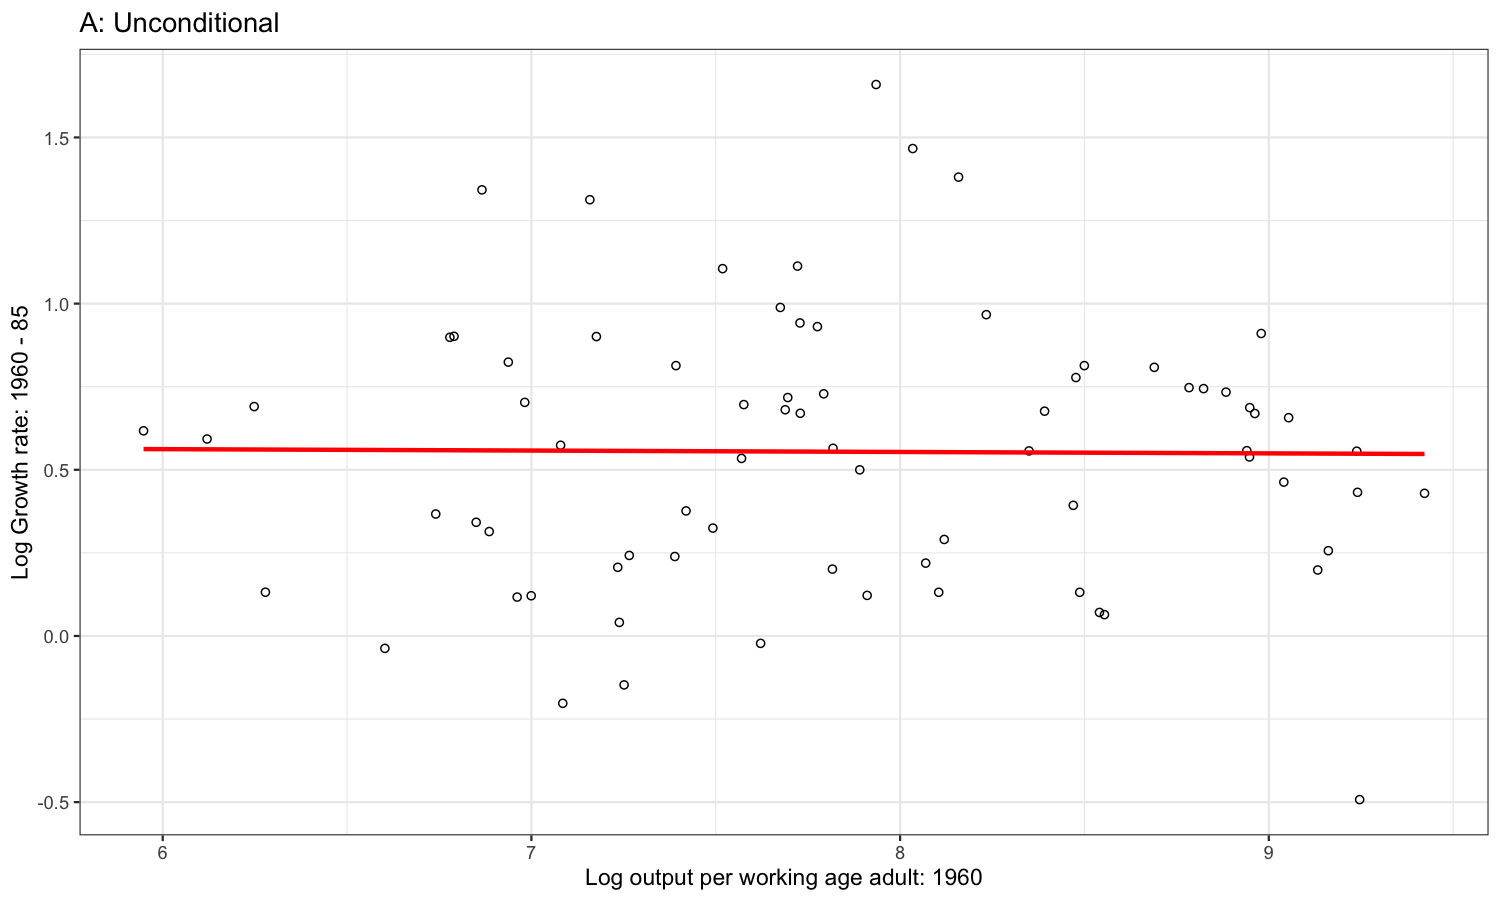

In [56]:
ggplot(intermediate, aes(x = ln_gdp_60, y = ln_gdp_growth)) +
    geom_point(shape = 1) +
    geom_smooth(method=lm, se=FALSE, color = "red") +
    theme_bw() +
    ggtitle("A: Unconditional") +
    ylab("Log Growth rate: 1960 - 85") +
    xlab("Log output per working age adult: 1960")

In [57]:
y2 <- lm(ln_gdp_growth ~  ln_inv_gdp + ln_ndg, data = intermediate)$residuals
x2 <- lm(ln_gdp_60 ~  ln_inv_gdp + ln_ndg, data = intermediate)$residuals

panel_b <- tibble(y2, x2)

`geom_smooth()` using formula = 'y ~ x'


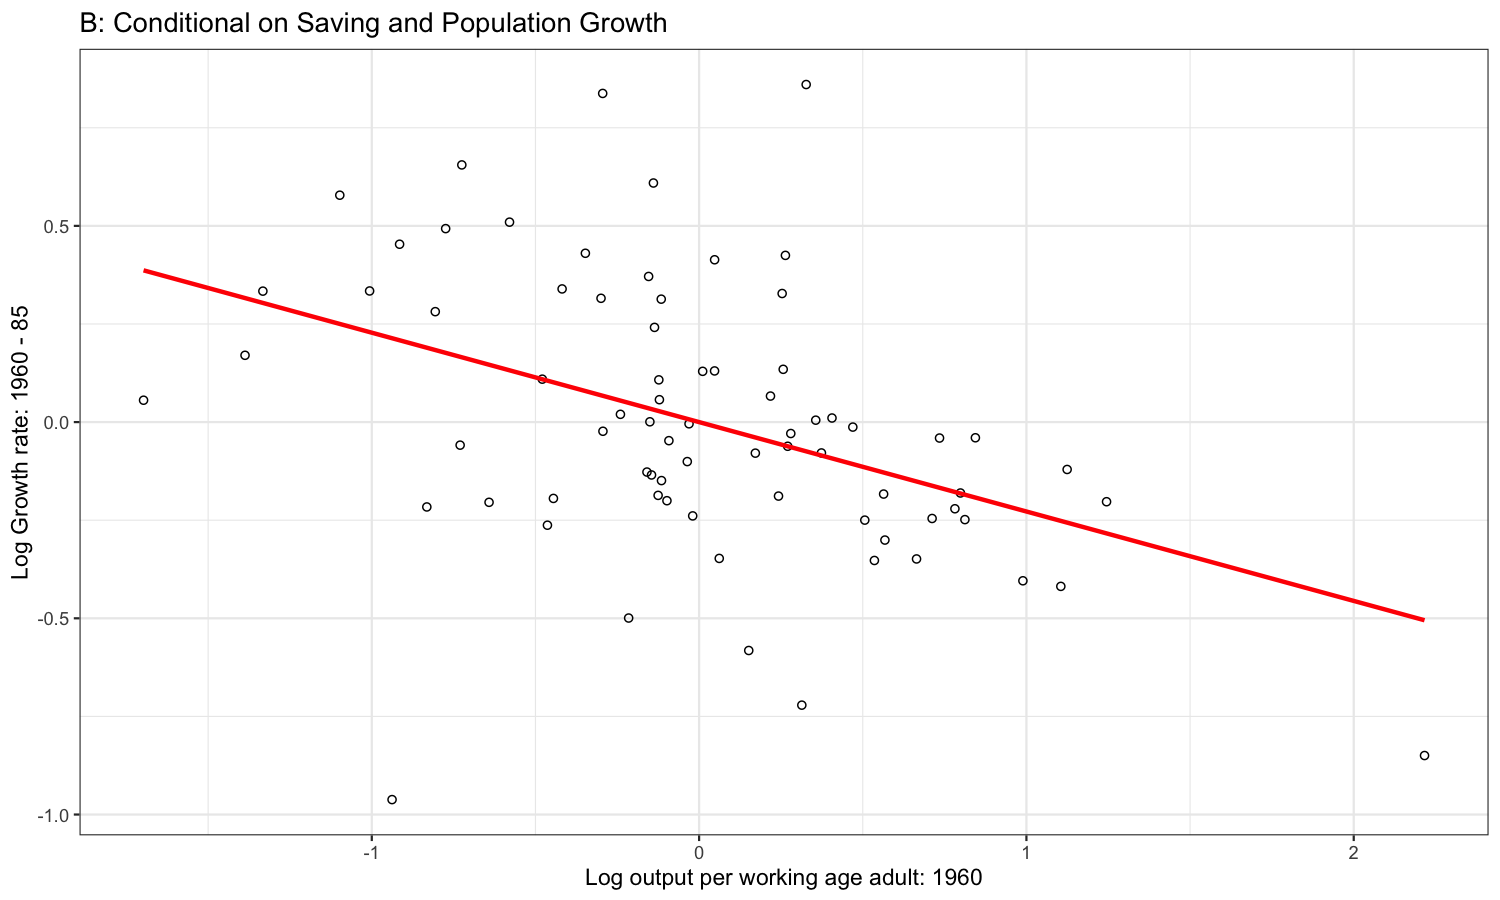

In [58]:
ggplot(panel_b, aes(x = x2, y = y2)) +
    geom_point(shape = 1) +
    geom_smooth(method=lm, se=FALSE, color = "red") +
    theme_bw() +
    ggtitle("B: Conditional on Saving and Population Growth") +
    ylab("Log Growth rate: 1960 - 85") +
    xlab("Log output per working age adult: 1960")

In [59]:
y3 <- lm(ln_gdp_growth ~  ln_inv_gdp + ln_ndg + ln_school, data = intermediate)$residuals
x3 <- lm(ln_gdp_60 ~  ln_inv_gdp + ln_ndg + ln_school, data = intermediate)$residuals

panel_c <- tibble(y3, x3)

`geom_smooth()` using formula = 'y ~ x'


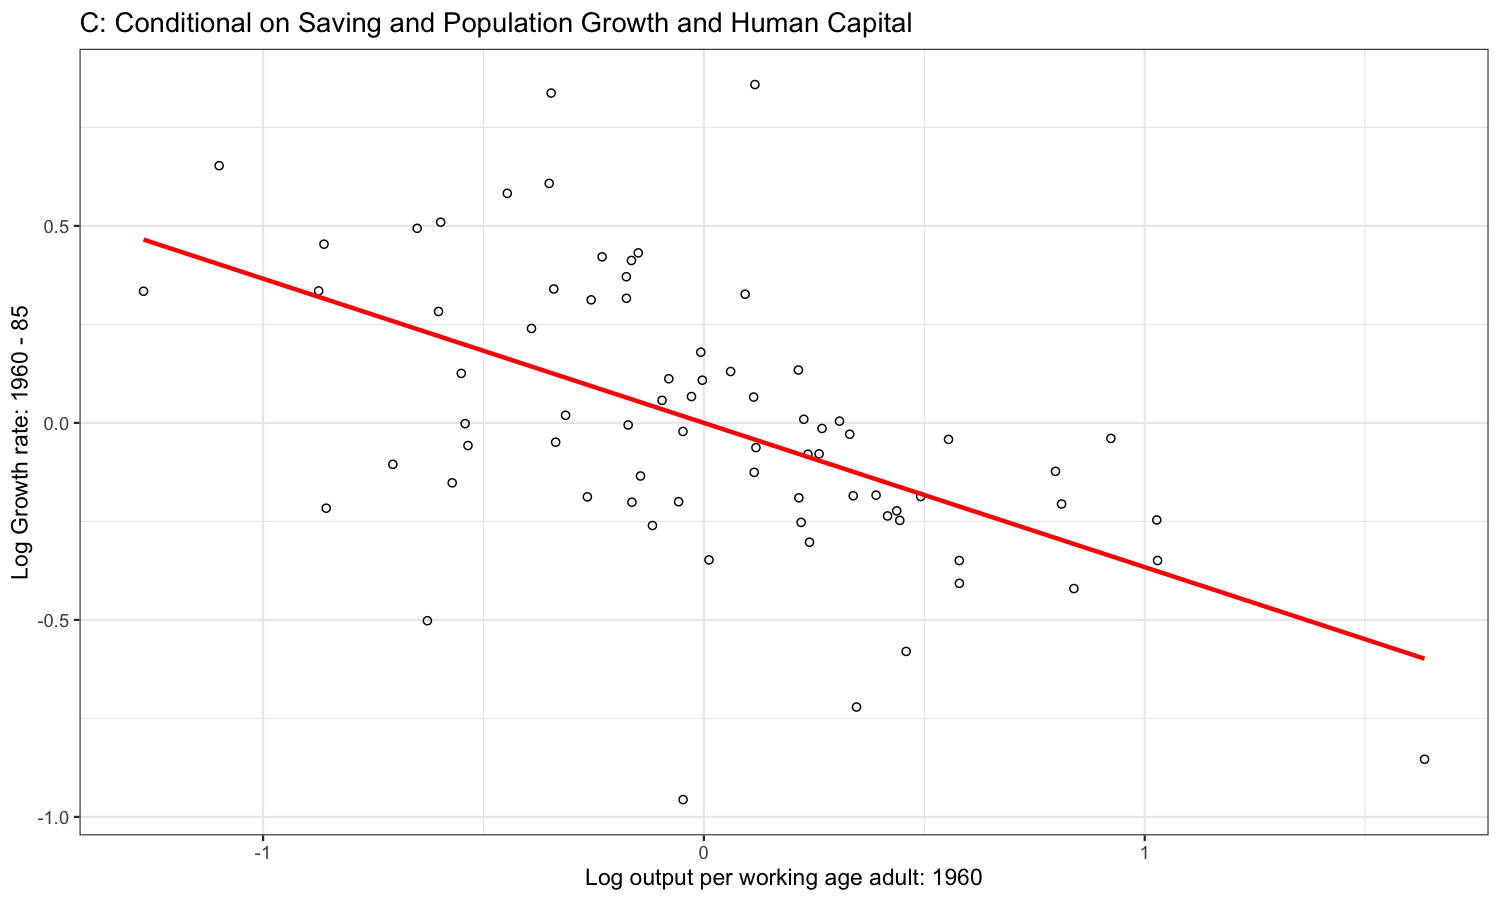

In [60]:
ggplot(panel_c, aes(x = x3, y = y3)) +
    geom_point(shape = 1) +
    geom_smooth(method=lm, se=FALSE, color = "red") +
    theme_bw() +
    ggtitle("C: Conditional on Saving and Population Growth and Human Capital") +
    ylab("Log Growth rate: 1960 - 85") +
    xlab("Log output per working age adult: 1960")

## Conclusions

Is the textbook Solow model consistent with the cross-country data?

- To some extent: the directions of the effects  are right.
- But, the magnitudes of the effects are over estimated.

What is the augmented Solow model? Is it consistent with the data?

- Yes

What are the implications of the Solow model for convergence in standards of living?

- Holding population growth and capital accumulation constant, poor countries tend to grow faster than rich countries. Countries tend to convergence at the rate predicted by the augmented Solow model.

- More than half (about 80 percent!!) of the cross-country variation in income per capita can be explained by differences in savings rates and population growth
    - "The augmented Solow models provides and almost complete explanation of why some countries are rich and other countries are poor"
    - The Solow model should not be dismissed in favor of endogenous growth models with constant or increasing marginal returns to capital.

Next question: What are the determinants of capital accumulation and technological change?

## Acknowledgements

The code of this notebook is based on that of [Lachlan Deer](https://lachlandeer.github.io/) & [Julian Langer](https://www.julianlanger.org/)